The code below will:

Read each CSV in the directory;
Skip files whose number of columns is not 9, whose region count is incorrect, or whose clause count is not 46;
Compute a region × region policy diff-rate matrix for each app;
Then compute the mean across the matrices of all apps;
Output to a single Excel file containing:

In [17]:
import pandas as pd
import numpy as np
from itertools import combinations
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter
from pathlib import Path

In [ ]:
input_folder  = Path(r"dataset\AA1_first_batch\out_openai_sematic_geodiff_txt") #"dataset\AA1_first_batch\AA2_second_100_batch\out_openai_sematic_geodiff_txt"
output_file = "dataset\\AA1_first_batch\\analysis_b_output\\behavior_difference_rate_results.xlsx"
# output_file = "dataset\\AA1_first_batch\AA2_second_100_batch\\analysis_b_output\\behavior_difference_results.xlsx"

def compute_diff_rate_matrix_from_policy(policy_df, clause_col="Clause"):
    mat = policy_df.set_index(clause_col)

    regions = list(mat.columns)
    num_clauses = mat.shape[0]

    mat = mat.astype(int)

    diff_rate_matrix = pd.DataFrame(
        np.zeros((len(regions), len(regions))),
        index=regions,
        columns=regions
    )

    for r1, r2 in combinations(regions, 2):
        diff_count = (mat[r1] != mat[r2]).sum()
        # diff_rate = diff_count
        diff_rate = diff_count / num_clauses


        diff_rate_matrix.loc[r1, r2] = diff_rate
        diff_rate_matrix.loc[r2, r1] = diff_rate

    return diff_rate_matrix


app_matrices = {}

for apk_dir in input_folder.iterdir():
    if not apk_dir.is_dir():
        continue

    apk_name = apk_dir.name

    # skip folders that are not APK package names
    if "." not in apk_name:
        print(f"[SKIP] Not an APK folder: {apk_dir}")
        continue

    app_files = sorted(apk_dir.glob("*_clause_region_matrix.csv")) 
    # print(f"\nProcessing APK: {apk_name} with {len(app_files)} application files.")


    app_name = app_files[0].stem
    # print(f"\nProcessing: {app_name}")

    try:
        # Read policy_df
        print(f"Processing {app_files[0]}...")
        policy_df = pd.read_csv(app_files[0])
        
        if policy_df.shape[1] != 12:
            print(f"Warning: {app_name} has {policy_df.shape[1]} regions, expected 12.")
            continue
        # print(policy_df.head())

        diff_rate_matrix = compute_diff_rate_matrix_from_policy(policy_df)

        if (diff_rate_matrix == 0).all().all():
            print(f"all is 0 for {app_name}, skipping.")
            continue

        print(f"Diff rate matrix for {app_name}:\n{diff_rate_matrix}")

        app_matrices[app_name] = diff_rate_matrix

    except Exception as e:
        print(f"[ERROR] {app_name}: {e}")

print("Number of apps:", len(app_matrices))

# average matrix
first_matrix = next(iter(app_matrices.values()))
avg_matrix = pd.DataFrame(
    np.zeros(first_matrix.shape),
    index=first_matrix.index,
    columns=first_matrix.columns
)

for app_name, matrix in app_matrices.items():
    avg_matrix += matrix

avg_matrix = avg_matrix / len(app_matrices)
# avg_matrix.to_csv("dataset\\AA1_first_batch\\analysis_b_output\\behavior_difference_rate_results.csv", index=True)

# save
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    avg_matrix.to_excel(writer, sheet_name="average_diff_rate")

    for app_name, matrix in app_matrices.items():
        sheet_name = str(app_name)[:31]
        matrix.to_excel(writer, sheet_name=sheet_name)

print(f"Saved to {output_file}")

Processing dataset\AA1_first_batch\out_openai_sematic_geodiff_txt\air.com.spilgames.TrollFaceQuestVideoGames2\air.com.spilgames.TrollFaceQuestVideoGames2_clause_region_matrix.csv...
all is 0 for air.com.spilgames.TrollFaceQuestVideoGames2_clause_region_matrix, skipping.
Processing dataset\AA1_first_batch\out_openai_sematic_geodiff_txt\alarm.clock.night.watch.talking\alarm.clock.night.watch.talking_clause_region_matrix.csv...
all is 0 for alarm.clock.night.watch.talking_clause_region_matrix, skipping.
Processing dataset\AA1_first_batch\out_openai_sematic_geodiff_txt\any.splitscreen\any.splitscreen_clause_region_matrix.csv...
Diff rate matrix for any.splitscreen_clause_region_matrix:
            California  Texas  Germany  Turkey  Egypt  Vietnam  Nigeria  \
California        0.00   0.00     0.00    0.00   0.00     0.00     0.00   
Texas             0.00   0.00     0.00    0.00   0.00     0.00     0.00   
Germany           0.00   0.00     0.00    0.00   0.00     0.00     0.00   
Turkey   

Each app × clause × region pair is one observation, and disclosed pairs and diff pairs are then aggregated by clause category.
For each clause category:
total pairs
disclosed pairs: at least one of the regions is 1
diff pairs: the two regions are different
disclosure rate
diff rate over total
diff rate among disclosed
Excel
Bar-chart PNG

Input: read app sheet names from the previously generated Excel file and include only the CSV files corresponding to those apps.

In [17]:
# app_matrices

In [18]:
from pathlib import Path
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
input_folder = Path(r"dataset\AA1_first_batch\out_openai_sematic_geodiff_txt")
app_matrix_file = Path(
    r"dataset\AA1_first_batch\analysis_b_output\behavior_difference_rate_results.xlsx"
)

output_file = Path(
    r"dataset\AA1_first_batch\analysis_b_output\behavior_category_difference_bar_chart.xlsx"
)
output_fig = output_file.with_suffix(".pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)


# Read the sheet names from the previously generated app_matrices output as the valid app list
xls = pd.ExcelFile(app_matrix_file)

exclude_sheets = {
    "average_diff_rate"
}

valid_app_names = {
    sheet for sheet in xls.sheet_names
    if sheet not in exclude_sheets
}

print(f"Apps selected from app_matrices sheets: {len(valid_app_names)}")

Apps selected from app_matrices sheets: 53


In [20]:
def get_clause_category(clause):
    clause = str(clause).strip()

    if clause.startswith("CR"):
        return "CR" #Controller & Recipient"
    elif clause.startswith("P"):
        return "P" #"Personal Data Practices"
    elif clause.startswith("C"):
        return  "C" #"Consent"
    elif clause.startswith("R") or clause.startswith("E"):
        return "R" #Rights
    else:
        return "O" #Others


summary = {}
detail_rows = []
used_apps = []
skipped_apps = []

In [21]:
for apk_dir in input_folder.iterdir():
    if not apk_dir.is_dir():
        continue

    apk_name = apk_dir.name

    # skip folders that are not APK package names
    if "." not in apk_name:
        print(f"[SKIP] Not an APK folder: {apk_dir}")
        continue
    
    # print(f"\n{app_name}")
    # Include only apps that appear in app_matrices
    # if app_name not in valid_app_names:
    #     continue
    for valid_app_name in valid_app_names:
        if valid_app_name not in apk_name:
            continue

    # print(f"\nProcessing APK: {apk_name} with {len(app_files)} application files.")

    app_files = sorted(apk_dir.glob("*_clause_region_matrix.csv")) 
    # print(f"\nProcessing APK: {apk_name} with {len(app_files)} application files.")


    app_name = app_files[0].stem
    # print(f"\nProcessing: {app_name}")

    try:
        # Read A
        policy_df = pd.read_csv(app_files[0])
        # print(f"[OK] {app_name}")

        if policy_df.shape[1] != 12:
            skipped_apps.append({
                "app": app_name,
                "reason": f"Expected 12 columns: Clause + 11 regions, got {policy_df.shape[1]}"
            })
            continue
        
        if "Clause" not in policy_df.columns:
            skipped_apps.append({
                "app": app_name,
                "reason": "Missing Clause column"
            })
            continue
        
        # if policy_df.shape[0] != 46:
        #     skipped_apps.append({
        #         "app": app_name,
        #         "reason": f"Expected 46 clauses, got {policy_df.shape[0]}"
        #     })
        #     continue

        print(f"Processing {app_name}...")

        region_cols = [c for c in policy_df.columns if c != "Clause"]
        policy_df[region_cols] = policy_df[region_cols].astype(int)
        policy_df["Category"] = policy_df["Clause"].apply(get_clause_category)

        used_apps.append(app_name)

        for _, row in policy_df.iterrows():
            category = row["Category"]

            if category not in summary:
                summary[category] = {
                    "total_pairs": 0,
                    "disclosed_pairs": 0,
                    "diff_pairs": 0
                }

            for r1, r2 in combinations(region_cols, 2):
                v1 = int(row[r1])
                v2 = int(row[r2])

                disclosed = int((v1 == 1) or (v2 == 1))
                diff = int(v1 != v2)

                summary[category]["total_pairs"] += 1
                summary[category]["disclosed_pairs"] += disclosed
                summary[category]["diff_pairs"] += diff

                detail_rows.append({
                    "app": app_name,
                    "clause": row["Clause"],
                    "category": category,
                    "region_1": r1,
                    "region_2": r2,
                    "value_1": v1,
                    "value_2": v2,
                    "disclosed": disclosed,
                    "diff": diff
                })

    except Exception as e:
        skipped_apps.append({
            "app": app_name,
            "reason": str(e)
        })



summary_df = pd.DataFrame.from_dict(summary, orient="index").reset_index()
summary_df = summary_df.rename(columns={"index": "category"})
print(summary_df["disclosed_pairs"], summary_df["total_pairs"])
summary_df["disclosure_rate"] = (
    summary_df["disclosed_pairs"] / summary_df["total_pairs"]
)

summary_df["diff_rate_over_total"] = (
    summary_df["diff_pairs"] / summary_df["total_pairs"]
)

summary_df["diff_rate_among_disclosed"] = (
    summary_df["diff_pairs"] / summary_df["disclosed_pairs"].replace(0, np.nan)
)

summary_df = summary_df.sort_values("diff_rate_over_total", ascending=False)

detail_df = pd.DataFrame(detail_rows)
used_apps_df = pd.DataFrame({"app": used_apps})
skipped_apps_df = pd.DataFrame(skipped_apps)

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="category_summary", index=False)
    detail_df.to_excel(writer, sheet_name="pair_level_details", index=False)
    used_apps_df.to_excel(writer, sheet_name="used_apps", index=False)
    skipped_apps_df.to_excel(writer, sheet_name="skipped_apps", index=False)

print(f"Used apps: {len(used_apps)}")
print(f"Skipped apps: {len(skipped_apps)}")
print(f"Saved Excel to: {output_file}")

Processing air.com.spilgames.TrollFaceQuestVideoGames2_clause_region_matrix...
Processing alarm.clock.night.watch.talking_clause_region_matrix...
Processing any.splitscreen_clause_region_matrix...
Processing app.phantom_clause_region_matrix...
Processing at.mobilkom.android.meina1_clause_region_matrix...
Processing authenticator.two.factor.authentication.otp_clause_region_matrix...
Processing azt.azt_clause_region_matrix...
Processing bage.image2pdf_clause_region_matrix...
Processing bg.emag.android_clause_region_matrix...
Processing bloodpressure.bloodpressureapppro.bloodpressureapp_clause_region_matrix...
Processing br.com.gringo_clause_region_matrix...
Processing br.com.mobile2you.appgas.costumer_clause_region_matrix...
Processing br.com.promobit.app_clause_region_matrix...
Processing br.tv.horizonte.android.premierefc_clause_region_matrix...
Processing bwebmedia.cookbakedlasagna_clause_region_matrix...
Processing by.green.tuber_clause_region_matrix...
Processing ca.tsn.mobile.andro

In [57]:
# # Plot the bar chart
# plot_df = summary_df.copy()

# x = np.arange(len(plot_df))
# width = 0.35

# plt.figure(figsize=(12, 6))
# plt.bar(x - width / 2, plot_df["total_pairs"], width, label="Total pairs")
# plt.bar(x - width / 2, plot_df["disclosed_pairs"], width, label="Disclosed pairs")
# plt.bar(x + width / 2, plot_df["diff_pairs"], width, label="Different pairs")

# plt.xticks(x, plot_df["category"], rotation=30, ha="right", fontsize=16)
# plt.ylabel("Observation Count", fontsize=16) # Number of app-clause-region-pair observations
# plt.title("Privacy Policy Disclosure and Difference by Clause Category", fontsize=16)
# plt.legend()
# plt.tight_layout()
# plt.savefig(output_fig)
# plt.show()

# print(f"Saved figure to: {output_fig}")

In [22]:
import pandas as pd
import numpy as np

output_file = Path(
    r"dataset\\AA1_first_batch\\analysis_b_output\B_category_difference_bar_chart.xlsx"
)
output_fig = output_file.with_suffix(".pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_excel("dataset\\AA1_first_batch\\analysis_b_output\\B_category_ave.xlsx")
summary_df.head()

,category,total_pairs,disclosed_pairs,diff_pairs,disclosure_rate,diff_rate_over_total,diff_rate_among_disclosed
0,P,127600,4127,2864,0.032343,0.022445,0.693967
1,CR,31900,439,328,0.013762,0.010282,0.747153
2,R,146740,27,24,0.000184,0.000164,0.888889
3,C,6380,0,0,0.000000,0.000000,NaN
4,O,6380,0,0,0.000000,0.000000,NaN


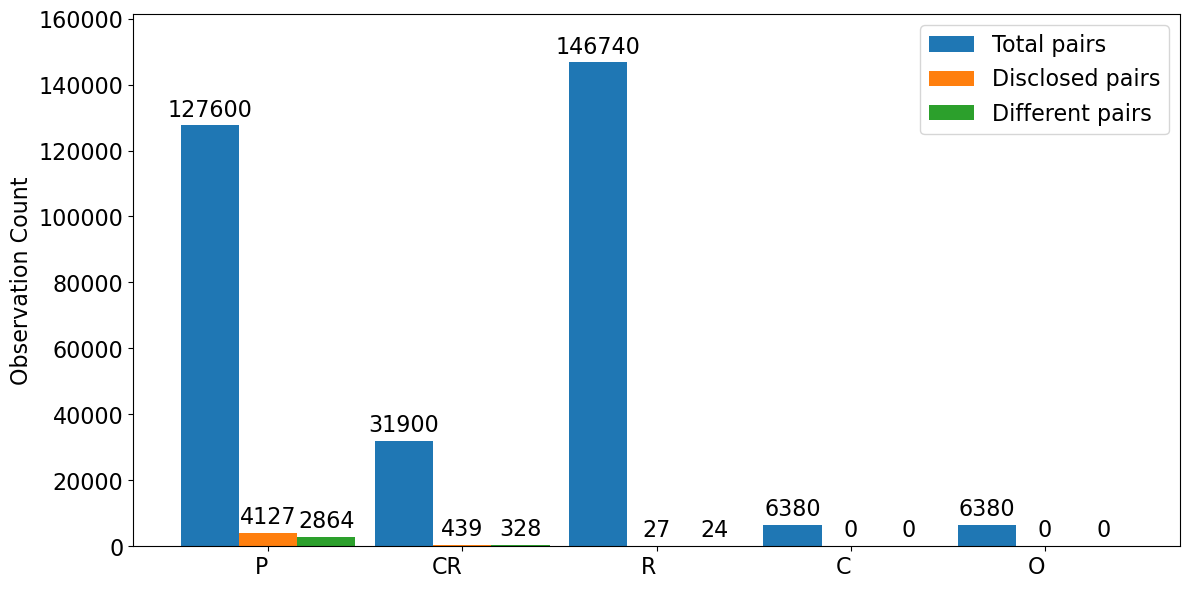

Saved figure to: dataset\AA1_first_batch\analysis_b_output\B_category_difference_bar_chart.pdf


In [23]:
# Plot the bar chart
plot_df = summary_df.copy()

x = np.arange(len(plot_df))
width = 0.30

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width,
    plot_df["total_pairs"],
    width,
    label="Total pairs"
)

bars2 = plt.bar(
    x ,
    plot_df["disclosed_pairs"],
    width,
    label="Disclosed pairs"
)

bars3 = plt.bar(
    x + width ,
    plot_df["diff_pairs"],
    width,
    label="Different pairs"
)

plt.bar_label(bars1, padding=3, fontsize=16)
plt.bar_label(bars2, padding=3, fontsize=16)
plt.bar_label(bars3, padding=3, fontsize=16)

ymax = plot_df[["total_pairs", "disclosed_pairs", "diff_pairs"]].to_numpy().max()
plt.ylim(0, ymax * 1.10)

plt.xticks(x, plot_df["category"], ha="right", fontsize=16)
plt.ylabel("Observation Count", fontsize=16) # Number of app-clause-region-pair observations
plt.yticks(fontsize=16)   # Enlarge the y-axis tick labels
# plt.title("Privacy Policy Disclosure and Difference by Clause Category", fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig(output_fig)
plt.show()

print(f"Saved figure to: {output_fig}")

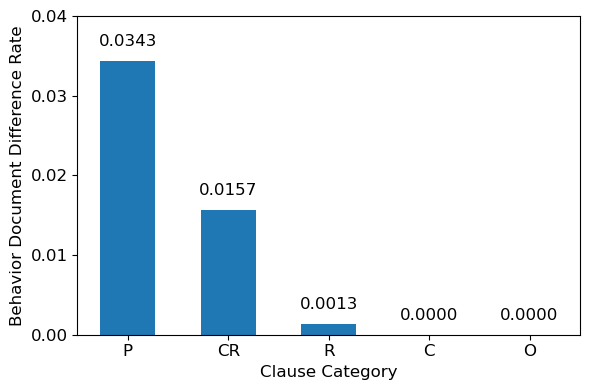

In [31]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

output_file = Path(
    r"dataset\AA1_first_batch\analysis_b_output\behavior_category_difference_bar_chart.xlsx"
)
# output_fig = output_file.with_suffix(".pdf")
output_file = Path(
    r"dataset\AA1_first_batch\analysis_b_output\behavior_category_difference_bar_chart3.xlsx"
)
output_file.parent.mkdir(parents=True, exist_ok=True)

categories = ["P", "CR", "R", "C", "O"]
diff_rates = [0.0343, 0.0157, 0.00134, 0, 0] #  PD 20, CR 5, C 2, R 16, O 3    36*20*31=22,320, 36*5*31=5,580, 36*2*31=2,232, 36*16*31=17,856, 36*3*31=3,348    914/22320=0.0409,  170/5580=0.0304,  0/2232=0,  0/17856=0,  0/3348=0

# app 116
# 36*20*116= 83,520, 36*5*116= 20,940, 36*2*116=2,340, 36*16*116=17,856, 36*3*116=3,348    
# cr 328/20,940= 0.0157
# p 2864/83,520= 0.0343    
# 0 0/2154=0       
# r 24/17,856=0.00134     
# c 0/3,348=0


fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, diff_rates, width=0.55)

ax.set_xlabel("Clause Category", fontsize=12)
ax.set_ylabel("Behavior Document Difference Rate", fontsize=12)

# Axis tick font size
ax.tick_params(axis="both", labelsize=12)

# Y-axis range and ticks
ax.set_ylim(0, 0.04)
ax.set_yticks(np.arange(0, 0.041, 0.01))

# Display values on the bars
for bar, value in zip(bars, diff_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0015,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()

plt.savefig(
    output_file.with_suffix(".pdf"),
    bbox_inches="tight"
)

plt.show()